<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/unsupervised/Unsupervised_Learning_2425_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 0: Preliminaries**

## Preamble: import useful packages and functions

In [3]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

In [4]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

In [7]:
os.chdir('/content/drive/MyDrive/Unsupervised')


In [8]:
!ls

'fortune500(2017-2021).csv'
'Unsupervised Learning - 2425 - Lab 01.ipynb'
'Unsupervised Learning - 2425 - Lab 01 - SOLUTION.ipynb'
 Untitled0.ipynb


## Load a .csv file

In [9]:
# Load the .csv file
df = pd.read_csv('fortune500(2017-2021).csv')

In [12]:
df[:2]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


## Transform the dataset into a Pandas DataFrame

In [15]:
# Transform your dataset into a Pandas DataFrame
pdf = pd.DataFrame(df)
pdf[:2]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


# **TASK1: Explore the dataset**

In [18]:
# Print the first 10 objects of the dataset with all their attributes
pdf[:2]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


In [36]:
pdf.head(2)

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


In [27]:
# print the last element of the dataset
pdf.values[len(pdf)-1]

array([2499, 500, 'ABM Industries', 5145.0, -0.03, 57.2, -0.25, 2281.0,
       2428.0, 110000.0, -15.0, -15.0, 2017], dtype=object)

In [38]:
pdf.tail(1)

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
2499,2499,500,ABM Industries,5145.0,-0.03,57.2,-0.25,2281.0,2428.0,110000.0,-15.0,-15.0,2017


In [29]:
# Print the last 10 objects of the dataset with all their attributes
pdf[-2:]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
2498,2498,499,Vistra Energy,5164.0,NaN,NaN,NaN,15167.0,6968.0,4431.0,NaN,NaN,2017
2499,2499,500,ABM Industries,5145.0,-0.03,57.2,-0.25,2281.0,2428.0,110000.0,-15.0,-15.0,2017


In [39]:
pdf.tail(2)

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
2498,2498,499,Vistra Energy,5164.0,NaN,NaN,NaN,15167.0,6968.0,4431.0,NaN,NaN,2017
2499,2499,500,ABM Industries,5145.0,-0.03,57.2,-0.25,2281.0,2428.0,110000.0,-15.0,-15.0,2017


### In an Array(Dataset)
**Object = Rows**

They represent:
* One Sample
* One data point
* One observation(One single data recorde)

👉 Each row = one object.

**Attributes = Columns**

They represent:
* Feature
* Variable
* Properties of the object

👉 Each column = one attribute.

In [40]:
# Describe the dataset (#objects, #attributes, data types)
# 1. Describe the dataset
pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  2500 non-null   int64  
 1   Rank                                        2500 non-null   int64  
 2   Name                                        2500 non-null   object 
 3   Revenues($M)                                2500 non-null   float64
 4   Revenue Percent Change                      2482 non-null   float64
 5   Profits ($M)                                2498 non-null   float64
 6   Profits Percent Change                      2211 non-null   float64
 7   Assets ($M)                                 2500 non-null   float64
 8   Market Value as of march 31st of that year  2361 non-null   float64
 9   Change in Rank (Full 1000)                  2398 non-null   float64
 10  Employees   

In [41]:
# Show the objects
pdf.shape

(2500, 13)

This says that `pdf` dataset have *2500* `object` and *13* `attribute`

In [45]:
# Data types
pdf.dtypes

,0
Unnamed: 0,int64
Rank,int64
Name,object
Revenues($M),float64
Revenue Percent Change,float64
Profits ($M),float64
Profits Percent Change,float64
Assets ($M),float64
Market Value as of march 31st of that year,float64
Change in Rank (Full 1000),float64


In [46]:
# Extract the profits (one single column). The exact title of the column is: "Profits ($M)". Using ' or " is equivalent here.
pdf['Profits ($M)'][:3]

,Profits ($M)
0,13510.0
1,21331.0
2,57411.0


In [47]:
# Extract only rows of a specific company

# 1. Get list all the companies name
pdf['Name'][:3]

,Name
0,Walmart
1,Amazon
2,Apple


In [51]:
# 2. Extract only rows of a specific company
pdf[pdf.Name == "Walmart"]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
500,500,1,Walmart,523964.0,0.02,14881.0,1.23,236495.0,321803.3,NaN,2200000.0,NaN,2020
1000,1000,1,Walmart,514405.0,0.03,6670.0,-0.32,219295.0,279880.3,NaN,2200000.0,NaN,2019
1500,1500,1,Walmart,500343.0,0.03,9862.0,-0.28,204522.0,263563.1,NaN,2300000.0,NaN,2018
2000,2000,1,Walmart,485873.0,0.01,13643.0,-0.07,198825.0,218619.0,2300000.0,NaN,NaN,2017


In [76]:
pdf[pdf['Year'] == 2021][:2]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


In [80]:
# Count the number of items you have per each "year". There are 5 years monitored, i.e., from 2017 to 2021. Hint: .value_counts()
pdf['Year'].value_counts()

,count
Year,
2021,500
2020,500
2019,500
2018,500
2017,500


In [10]:
# Repeat the same as above, but print the normalized value (as a percentage of the total number of objects, i.e., the number of rows)
pdf = pd.DataFrame(df)
pdf.isna().any()


,0
Unnamed: 0,False
Rank,False
Name,False
Revenues($M),False
Revenue Percent Change,True
Profits ($M),True
Profits Percent Change,True
Assets ($M),False
Market Value as of march 31st of that year,True
Change in Rank (Full 1000),True


In [23]:
pdf.columns[pdf.isna().any()]

Index(['Revenue Percent Change', 'Profits ($M)', 'Profits Percent Change',
       'Market Value as of march 31st of that year',
       'Change in Rank (Full 1000)', 'Employees', 'Change in Rank (500 only)'],
      dtype='object')

In [41]:
# Return all rows whose specific columns hav empty value
empty_revenue_percent = pdf[pdf['Revenue Percent Change'].isna()]
print(f'{(len(empty_revenue_percent)/len(pdf))*100}% is have empty Revenue Perecent Change\n Total {len(empty_revenue_percent)} object')
empty_revenue_percent[:5]

0.72% is have empty Revenue Perecent Change
 Total 18 object


,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
170,170,171,Carrier Global,17456.0,NaN,1982.0,NaN,25093.0,36701.1,NaN,56000.0,NaN,2021
235,235,236,Otis Worldwide,12756.0,NaN,906.0,NaN,10710.0,29418.4,NaN,69000.0,NaN,2021
253,253,254,Viatris,11946.0,NaN,-669.9,NaN,61553.0,16862.9,NaN,45000.0,NaN,2021
271,271,272,Xcel Energy,11526.0,NaN,1473.0,0.07,53957.0,35759.0,4.0,11367.0,4.0,2021
294,294,295,BorgWarner,10165.0,NaN,500.0,-0.33,16029.0,11081.0,17.0,49700.0,17.0,2021


In [43]:
# Normalize/Scale the specific columns
pdf.Year.value_counts(normalize=True)


,proportion
Year,
2021,0.2
2020,0.2
2019,0.2
2018,0.2
2017,0.2


# **TASK2: Manipulate the dataset**

In [59]:
## Let’s just rename those columns in a simpler way. See the guiding slides!
renamed_pdf = pdf.rename(columns={"Name": "New Name"})
renamed_pdf.tail(2)

,Unnamed: 0,Rank,New Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
2498,2498,499,Vistra Energy,5164.0,NaN,NaN,NaN,15167.0,6968.0,4431.0,NaN,NaN,2017
2499,2499,500,ABM Industries,5145.0,-0.03,57.2,-0.25,2281.0,2428.0,110000.0,-15.0,-15.0,2017


In [65]:
renamed_pdf.columns= ['id', 'rank', 'company', 'revenues', 'revenue_perc', 'profits', 'profit_perc', 'assets', 'market_value', 'change1000', 'employees', 'change500', 'year']
renamed_pdf.head(2)

,id,rank,company,revenues,revenue_perc,profits,profit_perc,assets,market_value,change1000,employees,change500,year
0,0,1,Walmart,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,NaN,2300000.0,NaN,2021
1,1,2,Amazon,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,NaN,1298000.0,NaN,2021


### **Handling NaN**

##Check for NaN under an entire DataFrame

In [51]:
# Check for NaN under an entire DataFrame
pdf.isna().any()


,0
Unnamed: 0,False
Rank,False
Name,False
Revenues($M),False
Revenue Percent Change,True
Profits ($M),True
Profits Percent Change,True
Assets ($M),False
Market Value as of march 31st of that year,True
Change in Rank (Full 1000),True


In [57]:
pdf[pdf['Profits ($M)'].isna()]

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
1990,1990,491,Peabody Energy,5578.8,0.18,NaN,NaN,8181.2,4648.8,42.0,7100.0,NaN,2018
2498,2498,499,Vistra Energy,5164.0,NaN,NaN,NaN,15167.0,6968.0,4431.0,NaN,NaN,2017


In [69]:
pdf.isna().tail(3)

,Unnamed: 0,Rank,Name,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
2497,False,False,False,False,False,False,True,False,False,False,False,True,False
2498,False,False,False,False,True,True,True,False,False,False,True,True,False
2499,False,False,False,False,False,False,False,False,False,False,False,False,False


In [73]:
# Count the number of NaN in the "profit" column
profit_null = renamed_pdf[renamed_pdf['profits'].isna()]
len(profit_null)

2

In [79]:
renamed_pdf['profits'].isna().sum(), renamed_pdf['profits'].isnull().sum()

(np.int64(2), np.int64(2))

In [23]:
# Compute the mean, min, max, and standard deviation profit of company = «ABM Industries» in 2017-2021. Use skipna=True to discard NaN entries.
# company data
company_data = pdf[pdf['Name']=="ABM Industries"]
# Company profit
company_profit = company_data['Profits ($M)']
# Mean
mean_profit = company_profit.mean()
# Max
max = company_profit.max()
# Standard Deviation
standard_deviation = company_profit.std()
standard_deviation

56.270596229291904

In [18]:
company_profit

,Profits ($M)
461,0.3
961,127.4
1462,97.8
1997,3.8
2499,57.2


In [17]:
# Mean can be calculate as sum of all values devided by number of values
company_profit.sum()/len(company_profit)

np.float64(57.3)

In [22]:
# Max can be calculated as well
max = -1
for i in company_profit:
  if(i>max):
    max = i
max

127.4

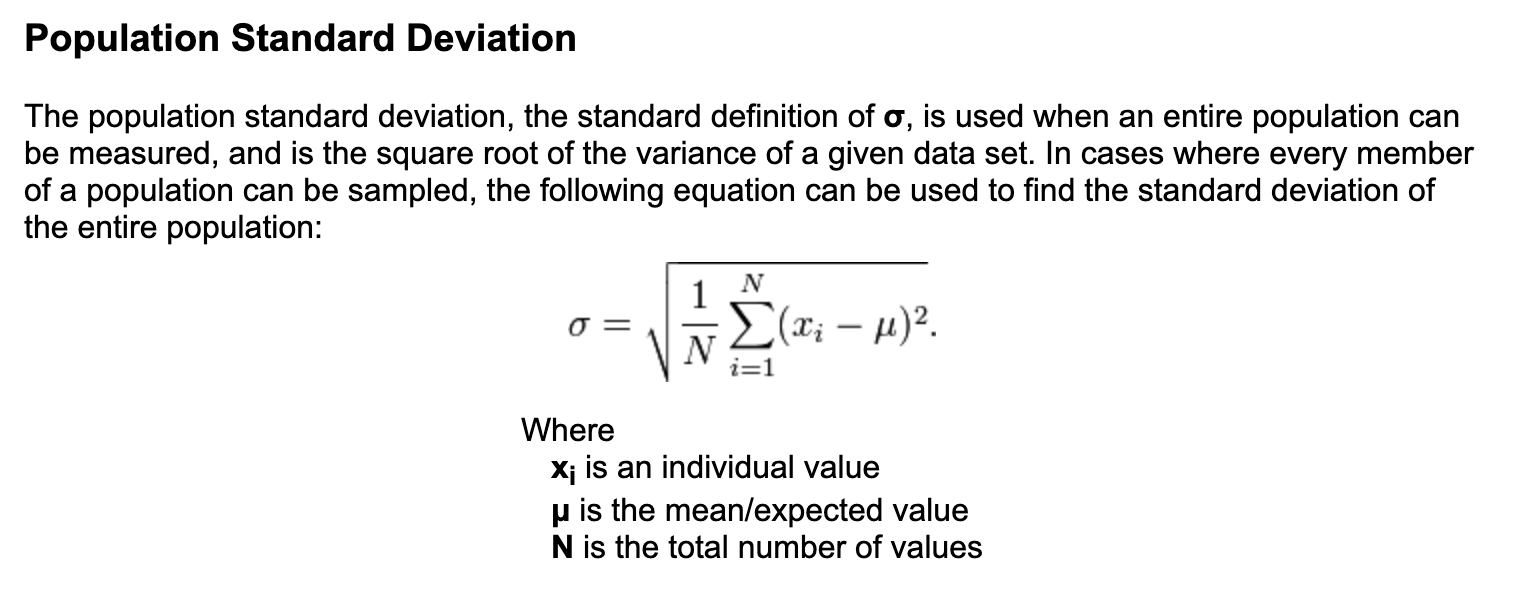

In [36]:
# Standard Deviation can be found in this way as well
# https://www.calculator.net/standard-deviation-calculator.html
sumation_squared = sum((xi - mean_profit)**2 for xi in company_profit)
std = np.sqrt(sumation_squared/(len(company_profit)-1))
std, standard_deviation


(np.float64(56.270596229291904), 56.270596229291904)

In [41]:
company_profit

,Profits ($M)
461,0.3
961,127.4
1462,97.8
1997,3.8
2499,57.2


In [45]:
company_profit

,Profits ($M)
461,0.3
961,127.4
1462,97.8
1997,3.8
2499,57.2


In [101]:
# Choose ONE COLUMN and decide how to scale it. You can opt for one either the four methods reported in the guiding slides.
#
# Initialize the scaler you want to use: MinMaxScaler(), StandardScaler(), RobustScaler(), Normalizer()
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
scaler = StandardScaler()
print(scaler.fit(company_profit.to_frame()))
scaler.mean_

StandardScaler()


array([57.3])

In [102]:
# Scale all numeric columns
numeric_data = pdf.select_dtypes(include='number')
# Fill all the NaN values with 0 or also can be filled with mean or median
numeric_data = numeric_data.fillna(0)
# Normalized the data
normalizer_scale = Normalizer()
norm = normalizer_scale.fit_transform(numeric_data)
norm[:2]

array([[ 0.00000000e+00,  4.14762618e-07,  2.31914933e-01,
         2.90333833e-08,  5.60344297e-03, -3.73286356e-08,
         1.04725902e-01,  1.58705930e-01,  0.00000000e+00,
         9.53954022e-01,  0.00000000e+00,  8.38235252e-04],
       [ 4.78635723e-07,  9.57271447e-07,  1.84784022e-01,
         1.81881575e-07,  1.02097786e-02,  4.02054008e-07,
         1.53735401e-01,  7.45747770e-01,  0.00000000e+00,
         6.21269169e-01,  0.00000000e+00,  9.67322797e-04]])

In [100]:
numeric_data[:3]

,Unnamed: 0,Rank,Revenues($M),Revenue Percent Change,Profits ($M),Profits Percent Change,Assets ($M),Market Value as of march 31st of that year,Change in Rank (Full 1000),Employees,Change in Rank (500 only),Year
0,0,1,559151.0,0.07,13510.0,-0.09,252496.0,382642.8,0.0,2300000.0,0.0,2021
1,1,2,386064.0,0.38,21331.0,0.84,321195.0,1558069.6,0.0,1298000.0,0.0,2021
2,2,3,274515.0,0.06,57411.0,0.04,323888.0,2050665.9,1.0,147000.0,1.0,2021


# **TASK 3: Visualize the dataframe**

Text(0.5, 1.0, 'All revenue')

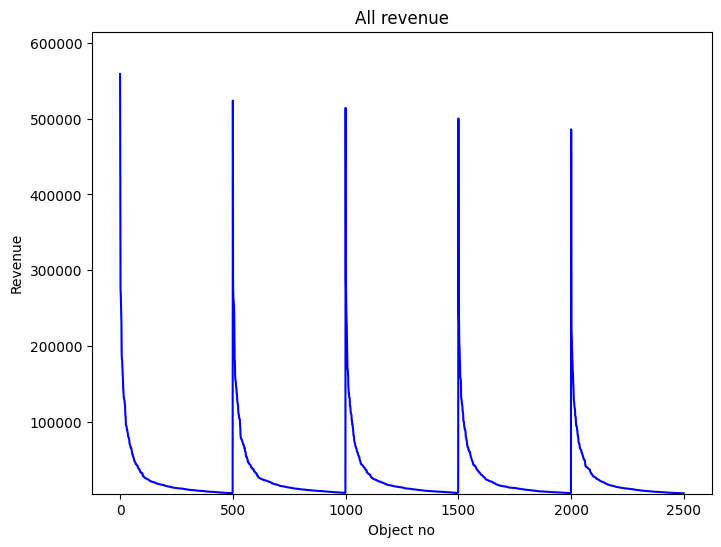

In [132]:
# Using Matplotlib, plot the revenues. Hint: plt.plot
# %matplotlib inline

# Extract the revenues
revenues = pdf['Revenues($M)']
MIN = 0.9*revenues.min()
MAX = 1.1*revenues.max()

# Plot the figure
plt.figure(figsize=(8, 6))
plt.plot(revenues, 'b-')
plt.ylim(MIN, MAX)
plt.ylabel("Revenue")
plt.xlabel("Object no")
plt.title("All revenue")


In [112]:
revenues[:5], MIN, MAX

(0    559151.0
 1    386064.0
 2    274515.0
 3    268706.0
 4    257141.0
 Name: Revenues($M), dtype: float64,
 4630.5,
 615066.1000000001)

/tmp/ipykernel_311/1142396720.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylim(MIN[0], MAX[0])
/tmp/ipykernel_311/1142396720.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlim(MIN[1], MAX[1])


Text(0, 0.5, 'Revenue')

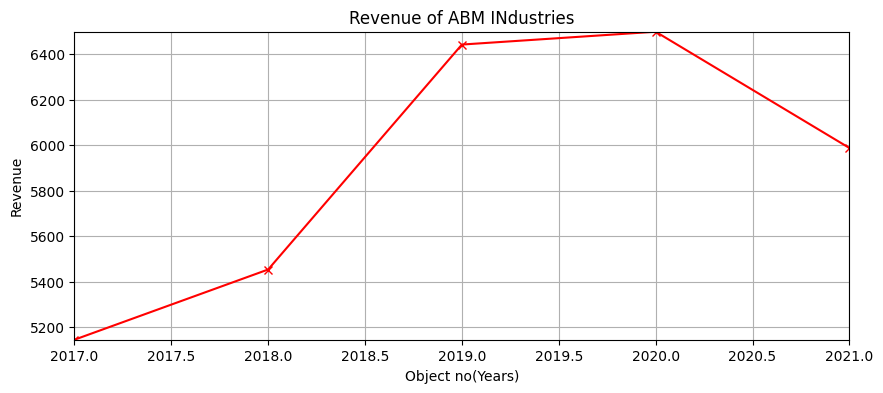

In [206]:
# Using Matplotlib, plot the revenues of a specific company (e.g., ABM Industries) in the years
company_rev = pdf[(pdf['Name'] == "ABM Industries") & (pdf['Year'] >= 2017) & (pdf['Year']<=2021)][['Revenues($M)', 'Year']]

MIN = company_rev.min()
MAX = company_rev.max()
plt.figure(figsize=(10, 4))
plt.plot(company_rev['Year'], company_rev['Revenues($M)'], 'rx-')
plt.ylim(MIN[0], MAX[0])
plt.xlim(MIN[1], MAX[1])
plt.grid()
plt.title("Revenue of ABM INdustries")
plt.xlabel("Object no(Years)")
plt.ylabel("Revenue")

In [173]:
company_rev

,Revenues($M),Year
461,5987.6,2021
961,6498.6,2020
1462,6442.2,2019
1997,5453.6,2018
2499,5145.0,2017


Text(0, 0.5, 'Profits')

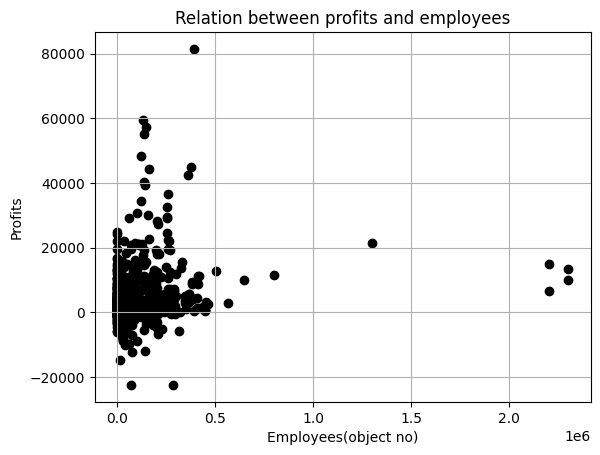

In [205]:
# Using Matplotlib, make a SCATTERPLOT to see if any trend exists between profits and employees. Hint: plt.scatter
profits = pdf['Profits ($M)']
employees = pdf['Employees']
plt.scatter(employees, profits, color="k")
plt.grid()
plt.title("Relation between profits and employees")
plt.xlabel("Employees(object no)")
plt.ylabel("Profits")

In [209]:
pd.DataFrame({"p": profits, "e": employees}).tail(4)

,p,e
2496,382.1,79.0
2497,-214.3,15.0
2498,NaN,NaN
2499,57.2,-15.0


In [212]:
import seaborn as sns

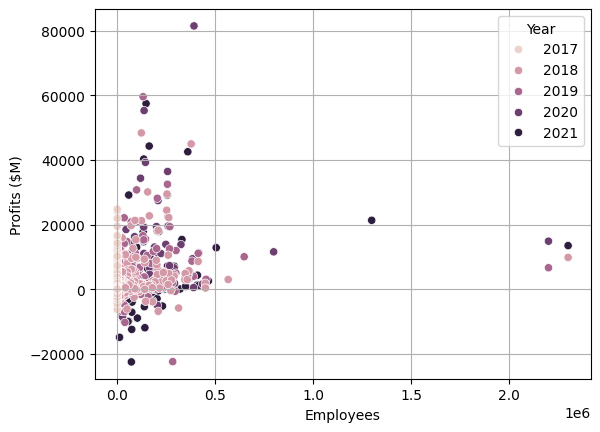

In [217]:
# Using Seaborn, repeat the SCATTERPLOT
sns.scatterplot(pdf, x="Employees", y="Profits ($M)", hue='Year')
plt.grid()



---


### **_This is the end of Lab#1 session._**


---



---